# Let me create an insurance DataFrame + define KPIs

In [43]:
import numpy as np
import pandas as pd

# Reproducibility
np.random.seed(42)

n_rows = 500

df = pd.DataFrame({
    "policy_id": range(1, n_rows + 1),
    "customer_age": np.random.randint(18, 80, size=n_rows),
    "gender": np.random.choice(["Male", "Female"], size=n_rows),
    "region": np.random.choice(["North", "South", "East", "West"], size=n_rows),
    "policy_type": np.random.choice(["Health", "Auto", "Home", "Life"], size=n_rows),
    "premium_amount": np.round(np.random.uniform(200, 3000, size=n_rows), 2),
    "sum_insured": np.round(np.random.uniform(10000, 500000, size=n_rows), 2),
    "tenure_years": np.random.randint(1, 11, size=n_rows),
    "claim_made": np.random.choice([0, 1], size=n_rows, p=[0.7, 0.3]),
    "claim_amount": np.round(np.random.uniform(0, 100000, size=n_rows), 2),
    "channel": np.random.choice(["Agent", "Online", "Branch"], size=n_rows),
})

# If no claim, set claim_amount to 0
df.loc[df["claim_made"] == 0, "claim_amount"] = 0.0


In [44]:
df.head().T

,0,1,2,3,4
policy_id,1,2,3,4,5
customer_age,56,69,46,32,60
gender,Female,Male,Female,Male,Male
region,South,South,West,South,South
policy_type,Health,Health,Health,Home,Home
premium_amount,2965.47,2843.37,310.4,2175.61,2790.7
sum_insured,361880.31,478206.61,18933.97,105931.21,13705.81
tenure_years,4,2,10,9,5
claim_made,0,0,0,0,1
claim_amount,0.0,0.0,0.0,0.0,30419.87


# Possible KPIs

Claim frequency: number of claims / number of policies (overall, by policy_type, by region, by channel).

Loss ratio: total claim_amount / total premium_amount (overall, by policy_type, by region).

Average premium per policy (overall, by policy_type, by age band, by channel).

Average premium per year (overall, by policy_type, by age_band, by channel).

Average claim amount per claim (overall and by policy_type).

Customer age distribution and count by policy_type.

Claim rate by age band and gender.



# Data understanding (EDA)

In [45]:
import pandas as pd

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)

print("\nMissing values per column:\n", df.isna().sum())

print("\nDescriptive statistics (numeric):")
display(df.describe())

print("\nCategorical value counts:")
for col in ["gender", "region", "policy_type", "channel"]:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())

# Claim rate and basic KPIs (quick view)
overall_claim_rate = df["claim_made"].mean()
print(f"\nOverall claim rate: {overall_claim_rate:.2%}")

avg_premium = df["premium_amount"].mean()
print(f"Average premium: {avg_premium:.2f}")

avg_claim_given_claim = df.loc[df["claim_made"] == 1, "claim_amount"].mean()
print(f"Average claim amount (only claims): {avg_claim_given_claim:.2f}")


Shape: (500, 11)

Data types:
 policy_id           int64
customer_age        int32
gender             object
region             object
policy_type        object
premium_amount    float64
sum_insured       float64
tenure_years        int32
claim_made          int64
claim_amount      float64
channel            object
dtype: object

Missing values per column:
 policy_id         0
customer_age      0
gender            0
region            0
policy_type       0
premium_amount    0
sum_insured       0
tenure_years      0
claim_made        0
claim_amount      0
channel           0
dtype: int64

Descriptive statistics (numeric):


,policy_id,customer_age,premium_amount,sum_insured,tenure_years,claim_made,claim_amount
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000
mean,250.500000,49.910000,1644.371480,252357.290800,5.428000,0.308000,15076.81456
std,144.481833,18.221909,830.051254,141457.442654,2.853261,0.462129,27722.13178
min,1.000000,18.000000,213.830000,11576.950000,1.000000,0.000000,0.00000
25%,125.750000,35.000000,888.350000,127754.135000,3.000000,0.000000,0.00000
50%,250.500000,50.000000,1690.680000,257062.600000,5.000000,0.000000,0.00000
75%,375.250000,66.000000,2360.365000,371351.687500,8.000000,1.000000,19650.09500
max,500.000000,79.000000,2998.360000,499190.280000,10.000000,1.000000,99718.24000



Categorical value counts:

Value counts for gender:
gender
Female    250
Male      250
Name: count, dtype: int64

Value counts for region:
region
South    137
East     131
North    130
West     102
Name: count, dtype: int64

Value counts for policy_type:
policy_type
Health    132
Home      130
Auto      126
Life      112
Name: count, dtype: int64

Value counts for channel:
channel
Branch    184
Online    162
Agent     154
Name: count, dtype: int64

Overall claim rate: 30.80%
Average premium: 1644.37
Average claim amount (only claims): 48950.70


# Data cleaning

In [46]:
import numpy as np

# Remove exact duplicate rows
df_clean = df.drop_duplicates().copy()

# Handle impossible ages or negative numbers if any (defensive checks)
df_clean = df_clean[(df_clean["customer_age"] >= 18) & (df_clean["customer_age"] <= 100)]

for col in ["premium_amount", "sum_insured", "claim_amount", "tenure_years"]:
    df_clean = df_clean[df_clean[col] >= 0]

# Ensure claim_amount is zero when no claim and > 0 when claim_made == 1
df_clean.loc[df_clean["claim_made"] == 0, "claim_amount"] = 0.0
df_clean.loc[(df_clean["claim_made"] == 1) & (df_clean["claim_amount"] == 0), "claim_amount"] = (
    df_clean.loc[(df_clean["claim_made"] == 1) & (df_clean["claim_amount"] == 0), "claim_amount"]
    .replace(0, df_clean["claim_amount"][df_clean["claim_amount"] > 0].median())
)

# Create useful derived columns
df_clean["age_band"] = pd.cut(
    df_clean["customer_age"],
    bins=[18, 25, 35, 45, 55, 65, 80],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66-80"],
    right=True,
)

df_clean["claim_severity"] = pd.cut(
    df_clean["claim_amount"],
    bins=[-0.01, 0, 5000, 20000, 100000, np.inf],
    labels=["No Claim", "Low", "Medium", "High", "Very High"],
)

# Final check
print("Shape after cleaning:", df_clean.shape)
print(df_clean.head())


Shape after cleaning: (500, 13)
   policy_id  customer_age  gender region policy_type  premium_amount  \
0          1            56  Female  South      Health         2965.47   
1          2            69    Male  South      Health         2843.37   
2          3            46  Female   West      Health          310.40   
3          4            32    Male  South        Home         2175.61   
4          5            60    Male  South        Home         2790.70   

   sum_insured  tenure_years  claim_made  claim_amount channel age_band  \
0    361880.31             4           0          0.00  Branch    56-65   
1    478206.61             2           0          0.00  Branch    66-80   
2     18933.97            10           0          0.00   Agent    46-55   
3    105931.21             9           0          0.00  Online    26-35   
4     13705.81             5           1      30419.87  Branch    56-65   

  claim_severity  
0       No Claim  
1       No Claim  
2       No Claim  
3 

In [47]:
df_clean.head().T

,0,1,2,3,4
policy_id,1,2,3,4,5
customer_age,56,69,46,32,60
gender,Female,Male,Female,Male,Male
region,South,South,West,South,South
policy_type,Health,Health,Health,Home,Home
premium_amount,2965.47,2843.37,310.4,2175.61,2790.7
sum_insured,361880.31,478206.61,18933.97,105931.21,13705.81
tenure_years,4,2,10,9,5
claim_made,0,0,0,0,1
claim_amount,0.0,0.0,0.0,0.0,30419.87


In [40]:
df_clean.head().T
df_clean.shape

(500, 13)

# cleaned Dataset generation

In [65]:
import pandas as pd

# 1. Reuse/encapsulate the cleaning logic into a function
def clean_insurance_data(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.drop_duplicates().copy()

    # Keep only valid ages
    df_clean = df_clean[(df_clean["customer_age"] >= 18) & (df_clean["customer_age"] <= 100)]

    # Remove negative numeric values
    for col in ["premium_amount", "sum_insured", "claim_amount", "tenure_years"]:
        df_clean = df_clean[df_clean[col] >= 0]

    # Enforce claim_amount logic
    df_clean.loc[df_clean["claim_made"] == 0, "claim_amount"] = 0.0

    median_claim = df_clean.loc[df_clean["claim_amount"] > 0, "claim_amount"].median()
    df_clean.loc[
        (df_clean["claim_made"] == 1) & (df_clean["claim_amount"] == 0),
        "claim_amount"
    ] = median_claim

    # Derived columns
    df_clean["age_band"] = pd.cut(
        df_clean["customer_age"],
        bins=[18, 25, 35, 45, 55, 65, 80],
        labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66-80"],
        right=True,
    )

    df_clean["claim_severity"] = pd.cut(
        df_clean["claim_amount"],
        bins=[-0.01, 0, 5000, 20000, 100000, float("inf")],
        labels=["No Claim", "Low", "Medium", "High", "Very High"],
    )

    return df_clean

# 2. Apply the cleaning function to generate the final cleaned dataset
final_df = clean_insurance_data(df)

print("Final cleaned dataset shape:", final_df.shape)
display(final_df.head())

# 3. Save to Excel (for use in other notebooks / ML work)
output_excel_path = "insurance_final_cleaned.xlsx"
final_df.to_excel(output_excel_path, index=False)  # keeps numeric dtypes; Excel decides numeric vs text [web:47][web:49][web:52][web:55][web:58][web:59]

print(f"Final cleaned dataset saved to {output_excel_path}")


Final cleaned dataset shape: (500, 15)


,policy_id,customer_age,gender,region,policy_type,premium_amount,sum_insured,tenure_years,claim_made,claim_amount,channel,age_band,claim_severity,loss_ratio,premium_per_year
0,1,56,Female,South,Health,2965.47,361880.31,4,0,0.00,Branch,56-65,No Claim,0.000000,741.367500
1,2,69,Male,South,Health,2843.37,478206.61,2,0,0.00,Branch,66-80,No Claim,0.000000,1421.685000
2,3,46,Female,West,Health,310.40,18933.97,10,0,0.00,Agent,46-55,No Claim,0.000000,31.040000
3,4,32,Male,South,Home,2175.61,105931.21,9,0,0.00,Online,26-35,No Claim,0.000000,241.734444
4,5,60,Male,South,Home,2790.70,13705.81,5,1,30419.87,Branch,56-65,High,10.900444,558.140000


Final cleaned dataset saved to insurance_final_cleaned.xlsx


In [68]:
import pandas as pd
import numpy as np

# 1) je charge mon fichier Excel existant
input_path = "insurance_final_cleaned.xlsx"   # nom du fichier actuel
df = pd.read_excel(input_path)

print("Colonnes avant ajout :", df.columns.tolist())

# 2) j'ajoute loss_ratio et premium_per_year
df["loss_ratio"] = np.where(
    df["premium_amount"] > 0,
    df["claim_amount"] / df["premium_amount"],
    0
)

df["premium_per_year"] = df["premium_amount"] / df["tenure_years"].replace(0, 1)

print("Colonnes après ajout :", df.columns.tolist())

# 3) je sauvegarde dans un nouveau fichier Excel
output_path = "insurance_cleaned_dataset generated.xlsx"
df.to_excel(output_path, index=False)

print(f"Nouveau fichier créé : {output_path}")


Colonnes avant ajout : ['policy_id', 'customer_age', 'gender', 'region', 'policy_type', 'premium_amount', 'sum_insured', 'tenure_years', 'claim_made', 'claim_amount', 'channel', 'age_band', 'claim_severity', 'loss_ratio', 'premium_per_year']
Colonnes après ajout : ['policy_id', 'customer_age', 'gender', 'region', 'policy_type', 'premium_amount', 'sum_insured', 'tenure_years', 'claim_made', 'claim_amount', 'channel', 'age_band', 'claim_severity', 'loss_ratio', 'premium_per_year']
Nouveau fichier créé : insurance_cleaned_dataset generated.xlsx


In [61]:
print(df.head())
print(df.shape)

   policy_id  customer_age  gender region policy_type  premium_amount  \
0          1            56  Female  South      Health         2965.47   
1          2            69    Male  South      Health         2843.37   
2          3            46  Female   West      Health          310.40   
3          4            32    Male  South        Home         2175.61   
4          5            60    Male  South        Home         2790.70   

   sum_insured  tenure_years  claim_made  claim_amount channel age_band  \
0    361880.31             4           0          0.00  Branch    56-65   
1    478206.61             2           0          0.00  Branch    66-80   
2     18933.97            10           0          0.00   Agent    46-55   
3    105931.21             9           0          0.00  Online    26-35   
4     13705.81             5           1      30419.87  Branch    56-65   

  claim_severity  loss_ratio  premium_per_year  
0       No Claim    0.000000        741.367500  
1       No C

# create KPI charts defined above & export Multi-page PDF report with insight and interpretations

Columns in df_clean:
['policy_id', 'customer_age', 'gender', 'region', 'policy_type', 'premium_amount', 'sum_insured', 'tenure_years', 'claim_made', 'claim_amount', 'channel', 'age_band', 'claim_severity', 'loss_ratio', 'premium_per_year']


C:\Users\horry\AppData\Local\Temp\ipykernel_80404\3294704983.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["claim_amount"].sum() / x["premium_amount"].sum()
C:\Users\horry\AppData\Local\Temp\ipykernel_80404\3294704983.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\horry\AppData\Local\Temp\ipykernel_80404\3294704983.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barp

PDF report generated: insurance_kpi_report.pdf
Total pages: 12


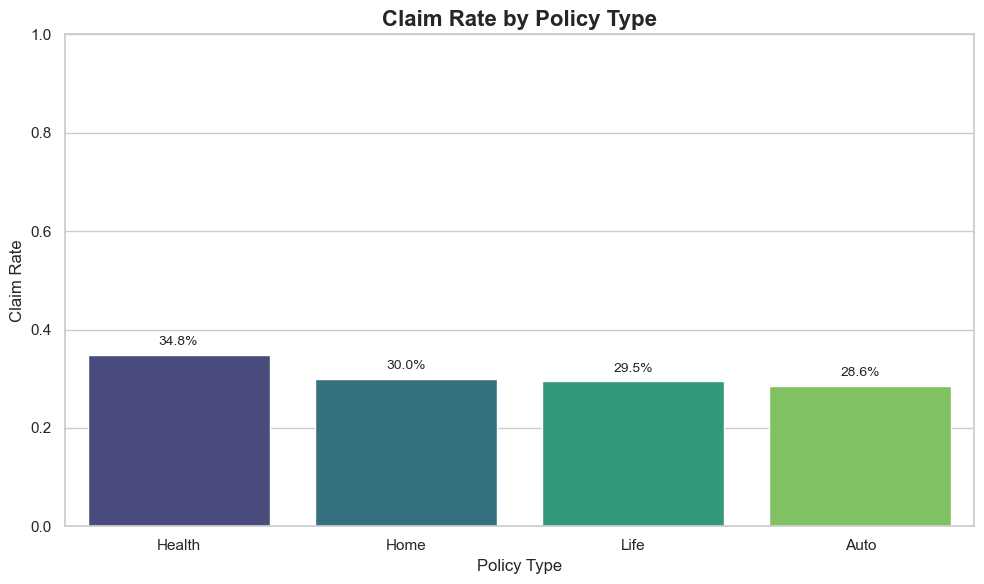

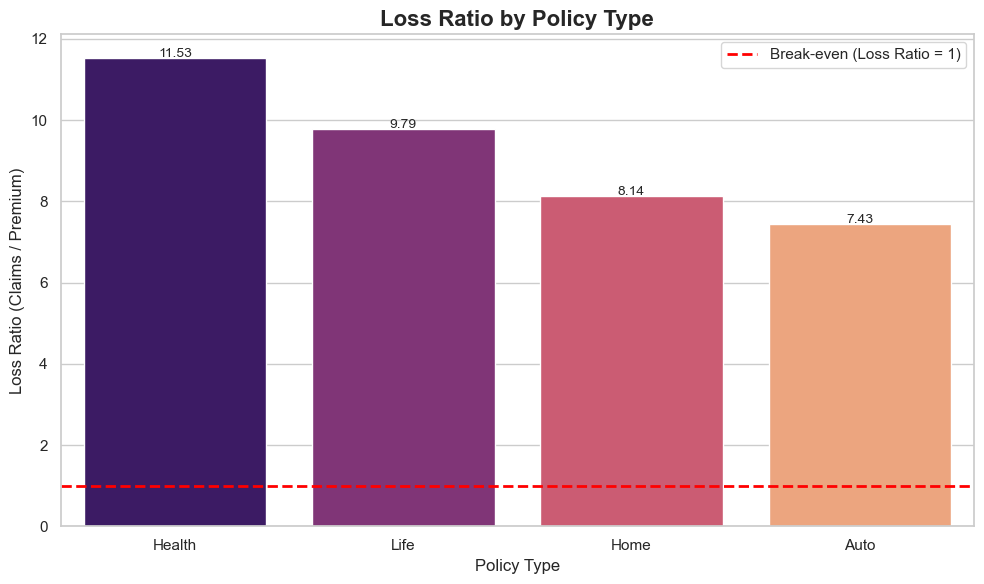

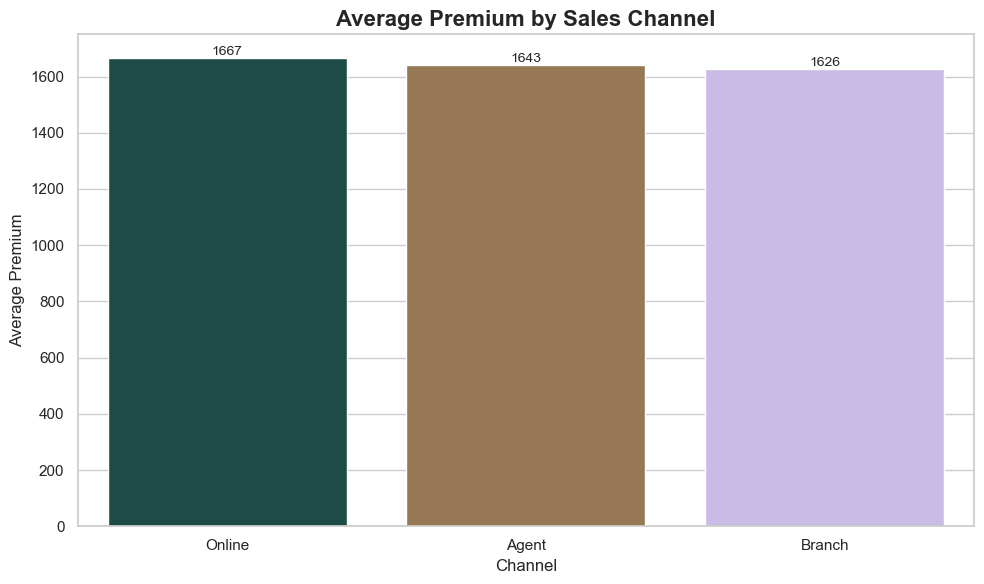

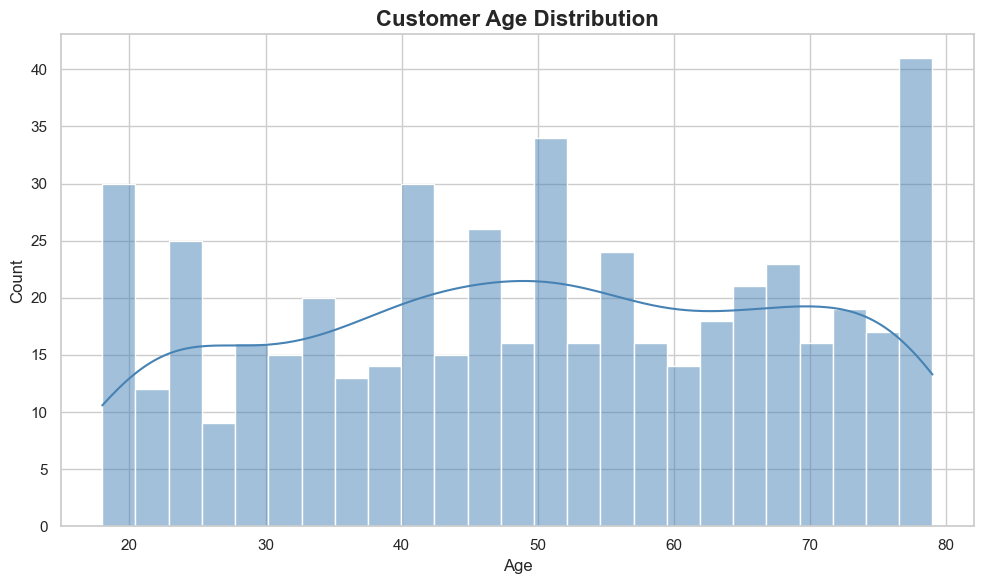

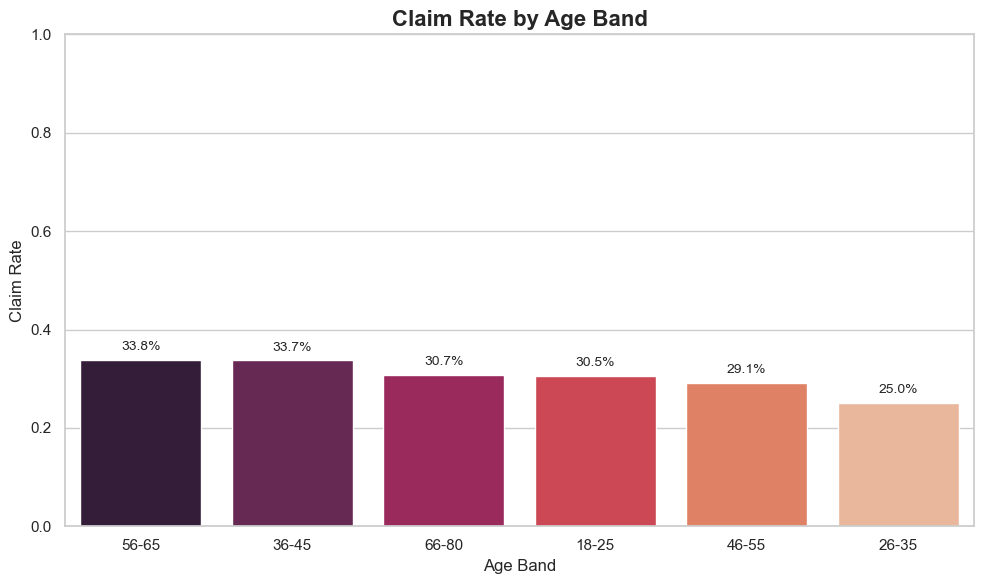

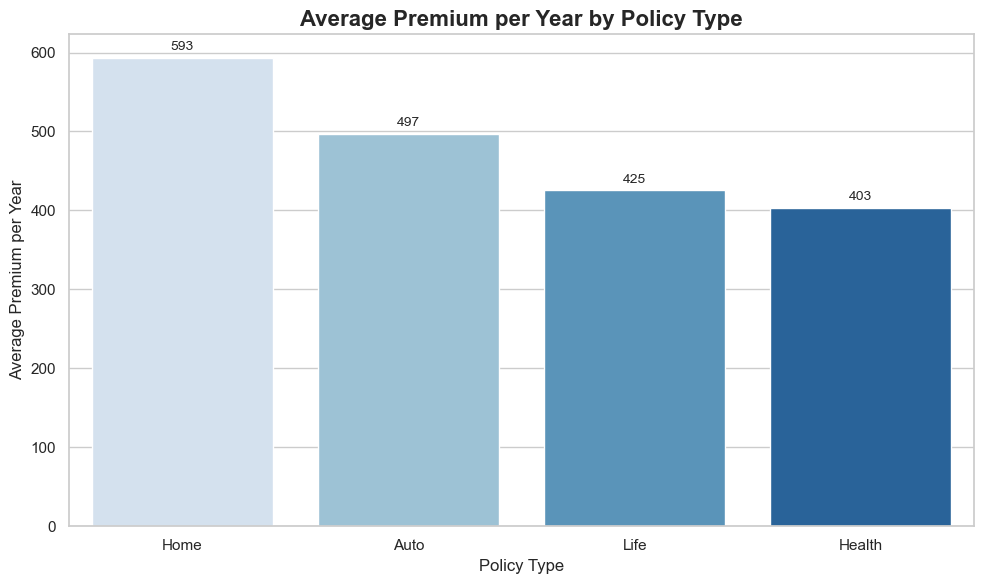

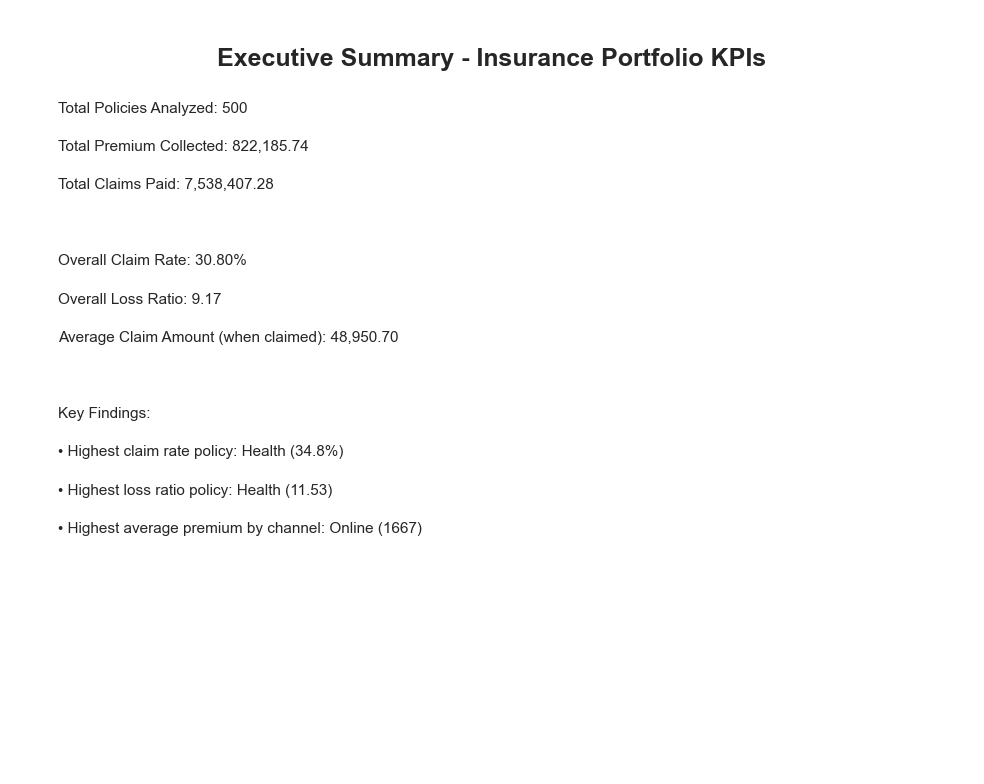

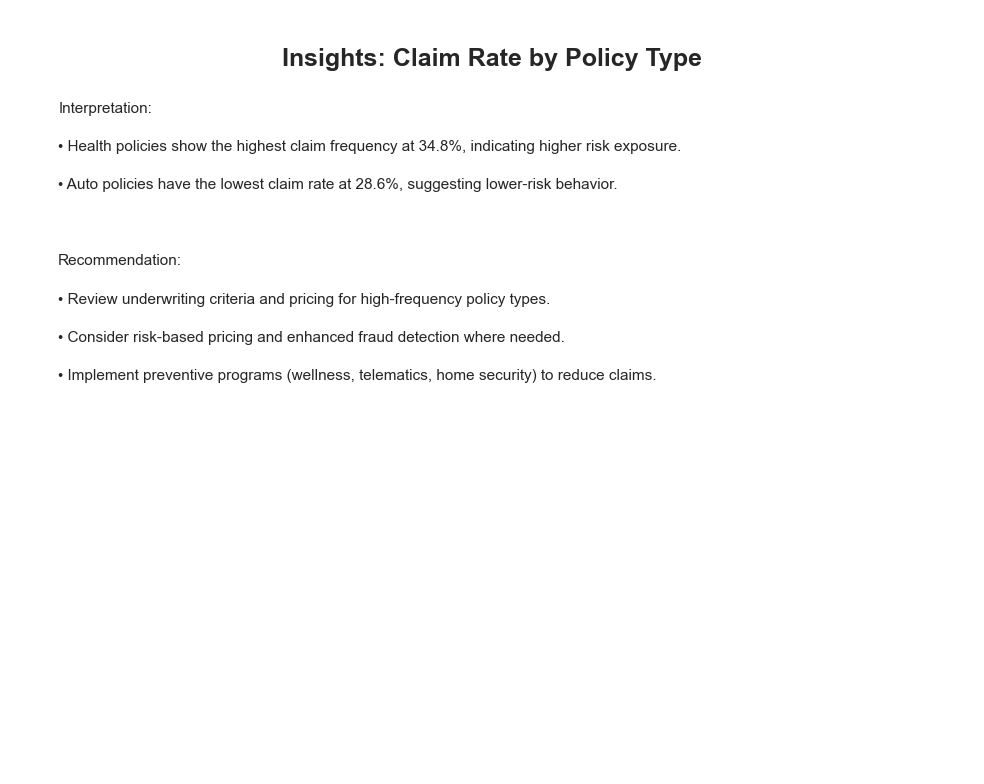

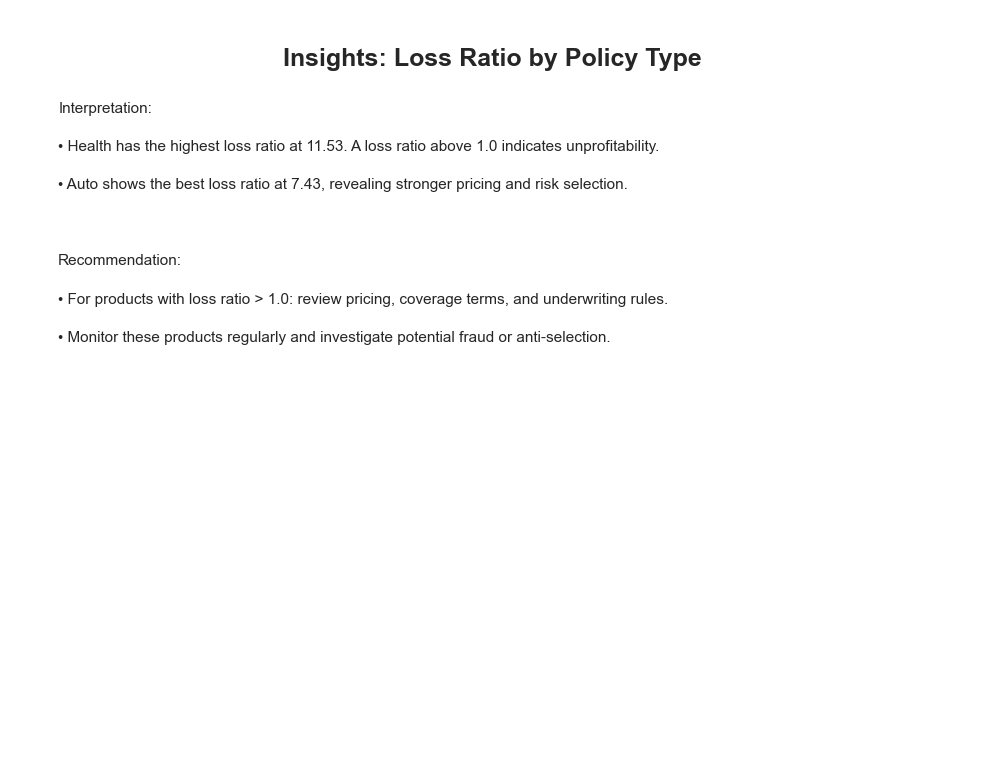

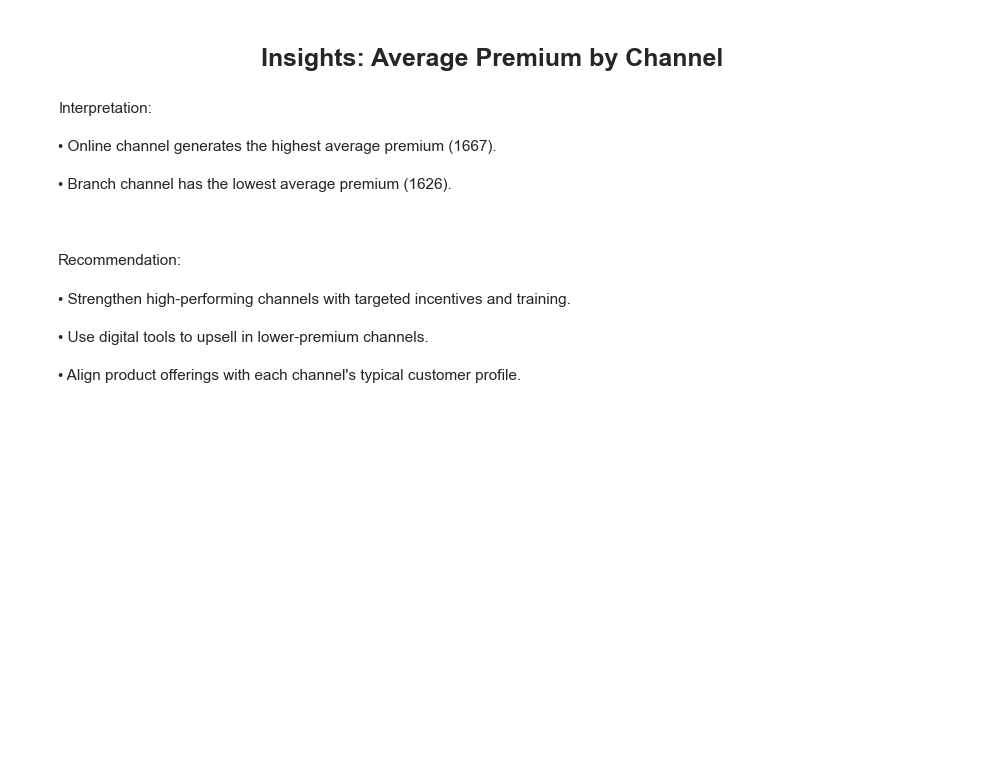

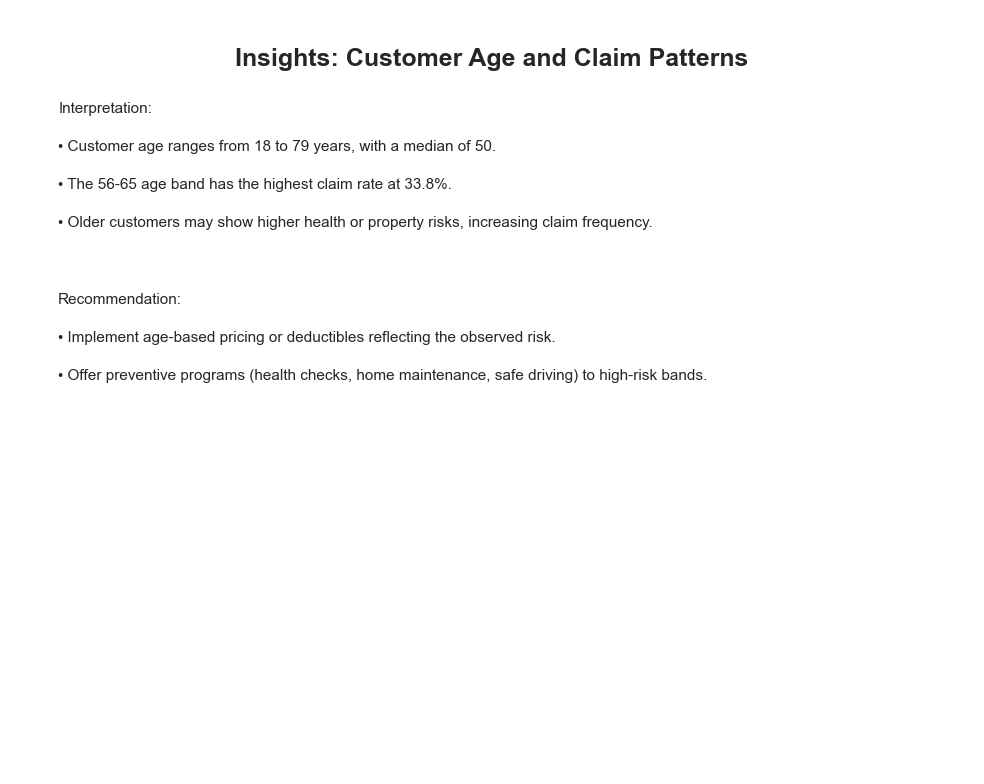

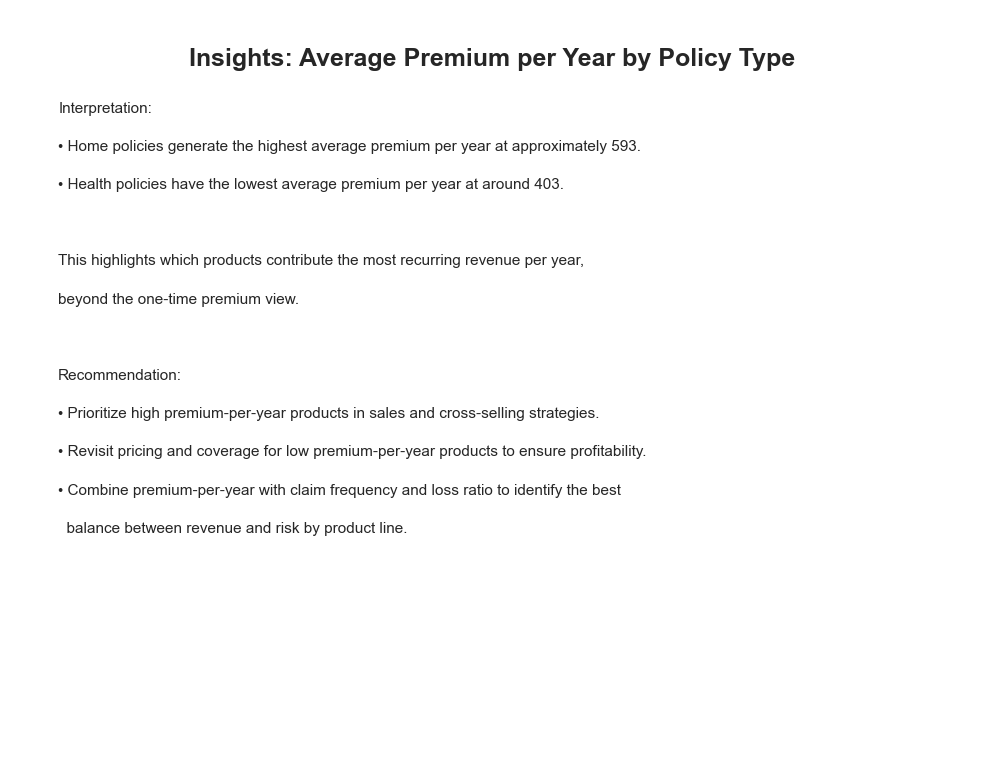

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

sns.set(style="whitegrid")

# ============================================================================
# 1. Load cleaned dataset (15 columns, including loss_ratio & premium_per_year)
# ============================================================================
input_path = "Insurance_cleaned_dataset generated.xlsx"
df_clean = pd.read_excel(input_path)

print("Columns in df_clean:")
print(df_clean.columns.tolist())

# ============================================================================
# 2. Compute KPIs from this dataset
# ============================================================================

total_policies = len(df_clean)
total_premium = df_clean["premium_amount"].sum()
total_claims_paid = df_clean["claim_amount"].sum()
overall_claim_rate = df_clean["claim_made"].mean()
overall_loss_ratio = total_claims_paid / total_premium if total_premium > 0 else 0

# Claim rate by policy_type
claim_rate_by_policy = (
    df_clean.groupby("policy_type")["claim_made"]
    .mean()
    .sort_values(ascending=False)
)

# Loss ratio by policy_type
loss_ratio_by_policy = (
    df_clean.groupby("policy_type")
    .apply(lambda x: x["claim_amount"].sum() / x["premium_amount"].sum()
           if x["premium_amount"].sum() > 0 else 0)
    .sort_values(ascending=False)
)

# Average premium by channel
avg_premium_by_channel = (
    df_clean.groupby("channel")["premium_amount"]
    .mean()
    .sort_values(ascending=False)
)

# Claim rate by age band
claim_rate_by_age = (
    df_clean.groupby("age_band")["claim_made"]
    .mean()
    .sort_values(ascending=False)
)

# Average claim amount given claim
avg_claim_given_claim = df_clean.loc[df_clean["claim_made"] == 1, "claim_amount"].mean()

# NEW: average premium_per_year by policy_type
avg_ppy_by_policy = (
    df_clean.groupby("policy_type")["premium_per_year"]
    .mean()
    .sort_values(ascending=False)
)

# For age summary
min_age = df_clean["customer_age"].min()
max_age = df_clean["customer_age"].max()
median_age = df_clean["customer_age"].median()

# ============================================================================
# 3. Create KPI charts
# ============================================================================

# Chart 1: Claim Rate by Policy Type
fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.barplot(
    x=claim_rate_by_policy.index,
    y=claim_rate_by_policy.values,
    ax=ax1,
    palette="viridis",
)
ax1.set_title("Claim Rate by Policy Type", fontsize=16, weight="bold")
ax1.set_xlabel("Policy Type", fontsize=12)
ax1.set_ylabel("Claim Rate", fontsize=12)
ax1.set_ylim(0, 1)
for i, v in enumerate(claim_rate_by_policy.values):
    ax1.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=10)
plt.tight_layout()

# Chart 2: Loss Ratio by Policy Type
fig2, ax2 = plt.subplots(figsize=(10, 6))
sns.barplot(
    x=loss_ratio_by_policy.index,
    y=loss_ratio_by_policy.values,
    ax=ax2,
    palette="magma",
)
ax2.set_title("Loss Ratio by Policy Type", fontsize=16, weight="bold")
ax2.set_xlabel("Policy Type", fontsize=12)
ax2.set_ylabel("Loss Ratio (Claims / Premium)", fontsize=12)
ax2.axhline(y=1.0, color="red", linestyle="--", linewidth=2, label="Break-even (Loss Ratio = 1)")
ax2.legend()
for i, v in enumerate(loss_ratio_by_policy.values):
    ax2.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)
plt.tight_layout()

# Chart 3: Average Premium by Channel
fig3, ax3 = plt.subplots(figsize=(10, 6))
sns.barplot(
    x=avg_premium_by_channel.index,
    y=avg_premium_by_channel.values,
    ax=ax3,
    palette="cubehelix",
)
ax3.set_title("Average Premium by Sales Channel", fontsize=16, weight="bold")
ax3.set_xlabel("Channel", fontsize=12)
ax3.set_ylabel("Average Premium", fontsize=12)
for i, v in enumerate(avg_premium_by_channel.values):
    ax3.text(i, v + 10, f"{v:.0f}", ha="center", fontsize=10)
plt.tight_layout()

# Chart 4: Customer Age Distribution
fig4, ax4 = plt.subplots(figsize=(10, 6))
sns.histplot(
    df_clean["customer_age"],
    kde=True,
    bins=25,
    ax=ax4,
    color="steelblue",
)
ax4.set_title("Customer Age Distribution", fontsize=16, weight="bold")
ax4.set_xlabel("Age", fontsize=12)
ax4.set_ylabel("Count", fontsize=12)
plt.tight_layout()

# Chart 5: Claim Rate by Age Band
fig5, ax5 = plt.subplots(figsize=(10, 6))
sns.barplot(
    x=claim_rate_by_age.index,
    y=claim_rate_by_age.values,
    ax=ax5,
    palette="rocket",
)
ax5.set_title("Claim Rate by Age Band", fontsize=16, weight="bold")
ax5.set_xlabel("Age Band", fontsize=12)
ax5.set_ylabel("Claim Rate", fontsize=12)
ax5.set_ylim(0, 1)
for i, v in enumerate(claim_rate_by_age.values):
    ax5.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=10)
plt.tight_layout()

# Chart 6 (NEW): Average Premium per Year by Policy Type
fig6, ax6 = plt.subplots(figsize=(10, 6))
sns.barplot(
    x=avg_ppy_by_policy.index,
    y=avg_ppy_by_policy.values,
    ax=ax6,
    palette="Blues",
)
ax6.set_title("Average Premium per Year by Policy Type", fontsize=16, weight="bold")
ax6.set_xlabel("Policy Type", fontsize=12)
ax6.set_ylabel("Average Premium per Year", fontsize=12)
for i, v in enumerate(avg_ppy_by_policy.values):
    ax6.text(i, v + 10, f"{v:.0f}", ha="center", fontsize=10)
plt.tight_layout()

# ============================================================================
# 4. Helper to create text-only insight pages
# ============================================================================

def create_text_page(title, content_lines, fig_size=(10, 8)):
    fig, ax = plt.subplots(figsize=fig_size)
    ax.axis("off")
    ax.text(0.5, 0.95, title, ha="center", va="top",
            fontsize=18, weight="bold", transform=ax.transAxes)
    y = 0.88
    for line in content_lines:
        ax.text(0.05, y, line, ha="left", va="top",
                fontsize=11, transform=ax.transAxes, wrap=True)
        y -= 0.05
    plt.tight_layout()
    return fig

# ============================================================================
# 5. Build insight pages (including premium_per_year)
# ============================================================================

# Executive summary
summary_lines = [
    f"Total Policies Analyzed: {total_policies:,}",
    f"Total Premium Collected: {total_premium:,.2f}",
    f"Total Claims Paid: {total_claims_paid:,.2f}",
    "",
    f"Overall Claim Rate: {overall_claim_rate:.2%}",
    f"Overall Loss Ratio: {overall_loss_ratio:.2f}",
    f"Average Claim Amount (when claimed): {avg_claim_given_claim:,.2f}",
    "",
    "Key Findings:",
    f"• Highest claim rate policy: {claim_rate_by_policy.idxmax()} "
    f"({claim_rate_by_policy.max():.1%})",
    f"• Highest loss ratio policy: {loss_ratio_by_policy.idxmax()} "
    f"({loss_ratio_by_policy.max():.2f})",
    f"• Highest average premium by channel: {avg_premium_by_channel.idxmax()} "
    f"({avg_premium_by_channel.max():.0f})",
]
fig_summary = create_text_page("Executive Summary - Insurance Portfolio KPIs", summary_lines)

# Insights: Claim Rate by Policy Type
insight_claim_rate = [
    "Interpretation:",
    f"• {claim_rate_by_policy.idxmax()} policies show the highest claim frequency "
    f"at {claim_rate_by_policy.max():.1%}, indicating higher risk exposure.",
    f"• {claim_rate_by_policy.idxmin()} policies have the lowest claim rate "
    f"at {claim_rate_by_policy.min():.1%}, suggesting lower-risk behavior.",
    "",
    "Recommendation:",
    "• Review underwriting criteria and pricing for high-frequency policy types.",
    "• Consider risk-based pricing and enhanced fraud detection where needed.",
    "• Implement preventive programs (wellness, telematics, home security) to reduce claims.",
]
fig_insight_claim = create_text_page("Insights: Claim Rate by Policy Type", insight_claim_rate)

# Insights: Loss Ratio by Policy Type
insight_loss_ratio = [
    "Interpretation:",
    f"• {loss_ratio_by_policy.idxmax()} has the highest loss ratio at "
    f"{loss_ratio_by_policy.max():.2f}. A loss ratio above 1.0 indicates unprofitability.",
    f"• {loss_ratio_by_policy.idxmin()} shows the best loss ratio at "
    f"{loss_ratio_by_policy.min():.2f}, revealing stronger pricing and risk selection.",
    "",
    "Recommendation:",
    "• For products with loss ratio > 1.0: review pricing, coverage terms, and underwriting rules.",
    "• Monitor these products regularly and investigate potential fraud or anti-selection.",
]
fig_insight_loss = create_text_page("Insights: Loss Ratio by Policy Type", insight_loss_ratio)

# Insights: Average Premium by Channel
insight_channel = [
    "Interpretation:",
    f"• {avg_premium_by_channel.idxmax()} channel generates the highest average premium "
    f"({avg_premium_by_channel.max():.0f}).",
    f"• {avg_premium_by_channel.idxmin()} channel has the lowest average premium "
    f"({avg_premium_by_channel.min():.0f}).",
    "",
    "Recommendation:",
    "• Strengthen high-performing channels with targeted incentives and training.",
    "• Use digital tools to upsell in lower-premium channels.",
    "• Align product offerings with each channel's typical customer profile.",
]
fig_insight_channel = create_text_page("Insights: Average Premium by Channel", insight_channel)

# Insights: Age and Claim Patterns
insight_age = [
    "Interpretation:",
    f"• Customer age ranges from {min_age} to {max_age} years, with a median of {median_age:.0f}.",
    f"• The {claim_rate_by_age.idxmax()} age band has the highest claim rate "
    f"at {claim_rate_by_age.max():.1%}.",
    "• Older customers may show higher health or property risks, increasing claim frequency.",
    "",
    "Recommendation:",
    "• Implement age-based pricing or deductibles reflecting the observed risk.",
    "• Offer preventive programs (health checks, home maintenance, safe driving) to high-risk bands.",
]
fig_insight_age = create_text_page("Insights: Customer Age and Claim Patterns", insight_age)

# Insights: Average Premium per Year by Policy Type (use of premium_per_year)
top_policy = avg_ppy_by_policy.idxmax()
top_value = avg_ppy_by_policy.max()
bottom_policy = avg_ppy_by_policy.idxmin()
bottom_value = avg_ppy_by_policy.min()

insight_ppy = [
    "Interpretation:",
    f"• {top_policy} policies generate the highest average premium per year "
    f"at approximately {top_value:.0f}.",
    f"• {bottom_policy} policies have the lowest average premium per year "
    f"at around {bottom_value:.0f}.",
    "",
    "This highlights which products contribute the most recurring revenue per year,",
    "beyond the one-time premium view.",
    "",
    "Recommendation:",
    "• Prioritize high premium-per-year products in sales and cross-selling strategies.",
    "• Revisit pricing and coverage for low premium-per-year products to ensure profitability.",
    "• Combine premium-per-year with claim frequency and loss ratio to identify the best",
    "  balance between revenue and risk by product line.",
]
fig_insight_ppy = create_text_page("Insights: Average Premium per Year by Policy Type", insight_ppy)

# ============================================================================
# 6. Export everything to a single multi-page PDF
# ============================================================================

output_pdf_path = "insurance_kpi_report.pdf"

figures_in_order = [
    fig_summary,          # 1 - Executive summary
    fig1,                 # 2 - Claim rate chart
    fig_insight_claim,    # 3 - Claim rate insights
    fig2,                 # 4 - Loss ratio chart
    fig_insight_loss,     # 5 - Loss ratio insights
    fig3,                 # 6 - Avg premium by channel chart
    fig_insight_channel,  # 7 - Channel insights
    fig4,                 # 8 - Age distribution chart
    fig5,                 # 9 - Claim rate by age band chart
    fig_insight_age,      # 10 - Age insights
    fig6,                 # 11 - Avg premium per year by policy type chart
    fig_insight_ppy,      # 12 - Premium per year insights
]

with PdfPages(output_pdf_path) as pdf:
    for fig in figures_in_order:
        pdf.savefig(fig, bbox_inches="tight")
    d = pdf.infodict()
    d["Title"] = "Insurance KPIs Report with insight"
    d["Author"] = "Horry Nobel"
    d["Subject"] = "Insurance portfolio analysis with extended KPIs"
    d["Keywords"] = "insurance, claims, premium, loss ratio, KPIs, premium_per_year"

print(f"PDF report generated: {output_pdf_path}")
print(f"Total pages: {len(figures_in_order)}")
